In [1]:
import numpy as np
import psfsim
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.interpolate as sp_itp
import scipy.integrate as sp_int

from psfsim.polychrom import PolychromaticPSF

In [2]:
j129 = np.linspace( 1.131, 1.454, 10 ) # microns

ps_size = 96
ovsamp = pixel_size = 8
mag = 1e8 # electrons from CCDs, use a large number (above 1e9) to get rid of any noticeable poisson effect
step = 0.1 # degrees
borders = ( 0.2, 1. )

bound = ps_size // 2
center = np.array( ( ps_size // 2, ps_size // 2 ) )
flux_factor = pixel_size**2 * mag

In [ ]:
def line_coords( angle, bound, center=np.array( ( 0, 0 ) ) ):
    # since (0, 0) in data coords is top left instead of bottom left we must use clockwise rotations to get
    # a visually ccl rotation. However we will take a transpose later anyways so the rotation matrix def is ccl, as expected. How quaint
    angle = np.deg2rad( angle )
    # print( angle )
    line = np.zeros( ( 2, bound ) )
    line[0] = np.arange( bound )

    rotation = np.array( (
        ( np.cos( angle ), -np.sin( angle ) ),
        ( np.sin( angle ), np.cos( angle ) ),
    ) )

    if len( rotation.shape ) > 2:
        line = line.reshape( ( 1, 2, bound ) )

    # print( line.shape )
    # print( rotation.T.shape )
    
    return np.int32( rotation.T @ line ) + np.int32( np.reshape( center, ( 2, 1 ) ) )

def find_spikes( image, step, bound=1024, center=np.array( ( 0, 0 )  ), borders=( 0., 1. ), threshold=0.5, verbose=False ):
    angles = np.linspace( 0, 360, num=np.int32( 360. / step ), endpoint=False )

    lines = line_coords( angles, bound, center )
    image_analyze = image.T # imshow will display the image as row,col with 0,0 in top left. For our analysis we want (col,row).
    
    line_vals = image_analyze[ lines[:,0], lines[:,1] ]
    sums = np.sum( line_vals, axis=-1 )

    # 0 to 1 for these. Should I add a way to make it force 0 <= borders[0] < borders[1] <= 1?
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )

    sums = np.sum( line_vals[:, range_low:range_high ], axis=-1 )    
    '''
    This formula is slightly different from the midpoint formula from before. The formula defaults to 50%, using 50% recovers the original behavior. Other
    ways to do this include rejecting the lowest 10% of values or so. That one might be worth pursuing in the future. The goal is to keep this method as simple as possible--
    I do NOT want to start staring at noise to find spikes.

    There is another method that may be worth pursuing that involves a boxcar average that goes around the circle and might be able to correct for groups of spikes that are much
    higher or lower than the naive cutoff assumes.
    '''
    diff = np.max( sums ) - np.min( sums )
    cutoff = np.min( sums ) + ( diff * threshold )
    spike_indices = np.where( sums > cutoff )[0]
    spike_angles = angles[ spike_indices ]
    # print( np.diff( spike_angles ) )

    # try 3 degrees to tell differing spikes apart for now
    spike_angle_discriminator = 3.
    borders = np.where( np.diff( spike_angles ) > spike_angle_discriminator )[0]
    spike_groups = np.split( spike_angles, borders + 1 )
    spike_group_indices = np.split( spike_indices, borders + 1 )

    # print( f'Cutoff of {cutoff:.3f}' )
    # unfortunately this for loop is necessary unless theres a convenient package for jagged arrays
    spike_list = np.zeros( len( spike_groups ) )
    for i in np.arange( len( spike_groups ) ):

        idx_min_r = spike_group_indices[i][0]
        idx_max_l = spike_group_indices[i][-1]

        idx_min_l = idx_min_r - 1
        idx_max_r = idx_max_l + 1

        slope_left = ( sums[ idx_min_r ] - sums[ idx_min_l ] ) / step
        slope_right = ( sums[ idx_max_r ] - sums[ idx_max_l ] ) / step

        th_min = ( ( cutoff - sums[ idx_min_l ] ) / slope_left ) + angles[ idx_min_l ]
        th_max = ( ( cutoff - sums[ idx_max_l ] ) / slope_right ) + angles[ idx_max_l ]


        # spike_list[i] = np.median( spike_groups[i] )
        spike_list[i] = ( th_min + th_max ) / 2.

    # print( spike_list )
    if verbose:
        return sums, spike_angles, cutoff, spike_list
    else:
        return spike_list

def draw_ray( ax, angle, bound, center=np.array( ( 0, 0 ) ), borders=( 0., 1. ), **kwargs ):
    line = line_coords( angle, bound, center )
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )
    ax.plot( line[ 0, range_low:range_high ], line[ 1, range_low:range_high ], **kwargs )
    return

def downsample_2d_image( image, pixel_size=8 ): # ONLY WORKS ON 2D IMAGES
    subpixel_side = np.arange( pixel_size )
    subpixel_cols, subpixel_rows = np.meshgrid( subpixel_side, subpixel_side )

    dsamp_size = image.shape[0] // pixel_size
    pixels_side = np.arange( dsamp_size ) * pixel_size
    pixels_cols, pixels_rows = np.meshgrid( pixels_side, pixels_side )
    
    pixels_rows = pixels_rows[ :, :, np.newaxis ] # promote to 3D
    pixels_cols = pixels_cols[ :, :, np.newaxis ]
    
    idx_arr_subpixel_rows = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_rows.flatten( ) )
    idx_arr_subpixel_cols = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_cols.flatten( ) )
    
    idx_arr_rows = idx_arr_subpixel_rows + pixels_rows
    idx_arr_cols = idx_arr_subpixel_cols + pixels_cols
    
    pixelated_image = image[ idx_arr_rows, idx_arr_cols ]
    downsampled_image = np.mean( pixelated_image, axis=-1 )
    return downsampled_image

def poisson_resample_image( img, flux_factor ):
    # resamples an image where each pixel gets its own poisson distribution
    # this will change the scales around so that the resulting image has large positive values!!!! be aware
    rng = np.random.default_rng( )
    poisson_means = img * flux_factor

    resampled_img = rng.poisson( poisson_means, size=poisson_means.shape )
    return resampled_img


In [4]:
def compute_response_matrix( aberrations, ideal_spike_angles, psf_object, step, bound, center, **kwargs ):
    resp_matrix = np.zeros( ( 12, 5 ) )
    for i in np.arange( aberrations.size ):
        extra_aberrations = [ None, None, None, None, None ]
        extra_aberrations[i] = aberrations[i]
        
        psf_object.compute_poly_psf(
            postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
            ovsamp=8, extra_aberrations=extra_aberrations
        )
        
        psf_ovsamp = np.log10( np.abs( psf_object.chromatic_psf ) )
        psf = downsample_2d_image( psf_ovsamp, pixel_size=8 )
    
        spike_list = find_spikes( psf, step, bound, center, **kwargs )
        resp_matrix[:, i] = ( spike_list - ideal_spike_angles ) / aberrations[i]

    return resp_matrix

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


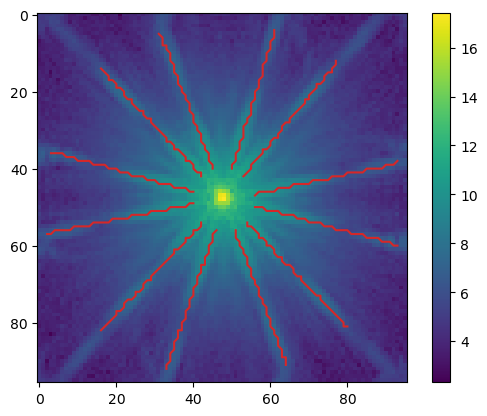

In [ ]:
j129_obj = PolychromaticPSF( 9,0,0, j129 )

j129_obj.compute_poly_psf( optical_psf_only=True, use_postage_stamp_size=ps_size, ovsamp=ovsamp, use_filter='J129' )
psf_ideal = np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) )


[ 12.29024797  50.40279232  72.80379388 111.47576712 133.35208743
 164.18580319 191.36832196 226.77144844 250.87455995 291.16004863
 314.00030467 344.83860418]


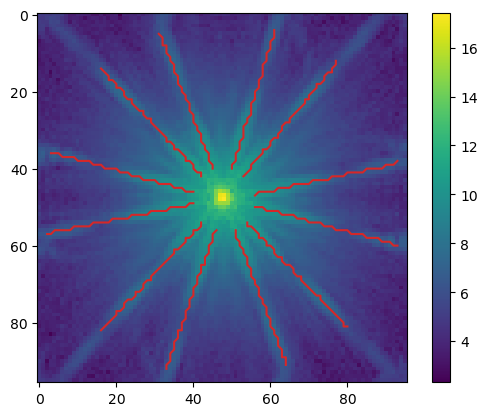

In [58]:

ideal_sums, _, _, ideal_spikes = find_spikes( psf_ideal, 0.1, bound, center, borders=borders, verbose=True )
print( ideal_spikes )

fig, ax = plt.subplots( )
im = ax.imshow( psf_ideal )
fig.colorbar( im, ax=ax )

for s in ideal_spikes:
    draw_ray( ax, s, bound, center, borders=borders, color='C3' )

Text(0.5, 1.0, 'Non-interpolated S($\\theta$)')

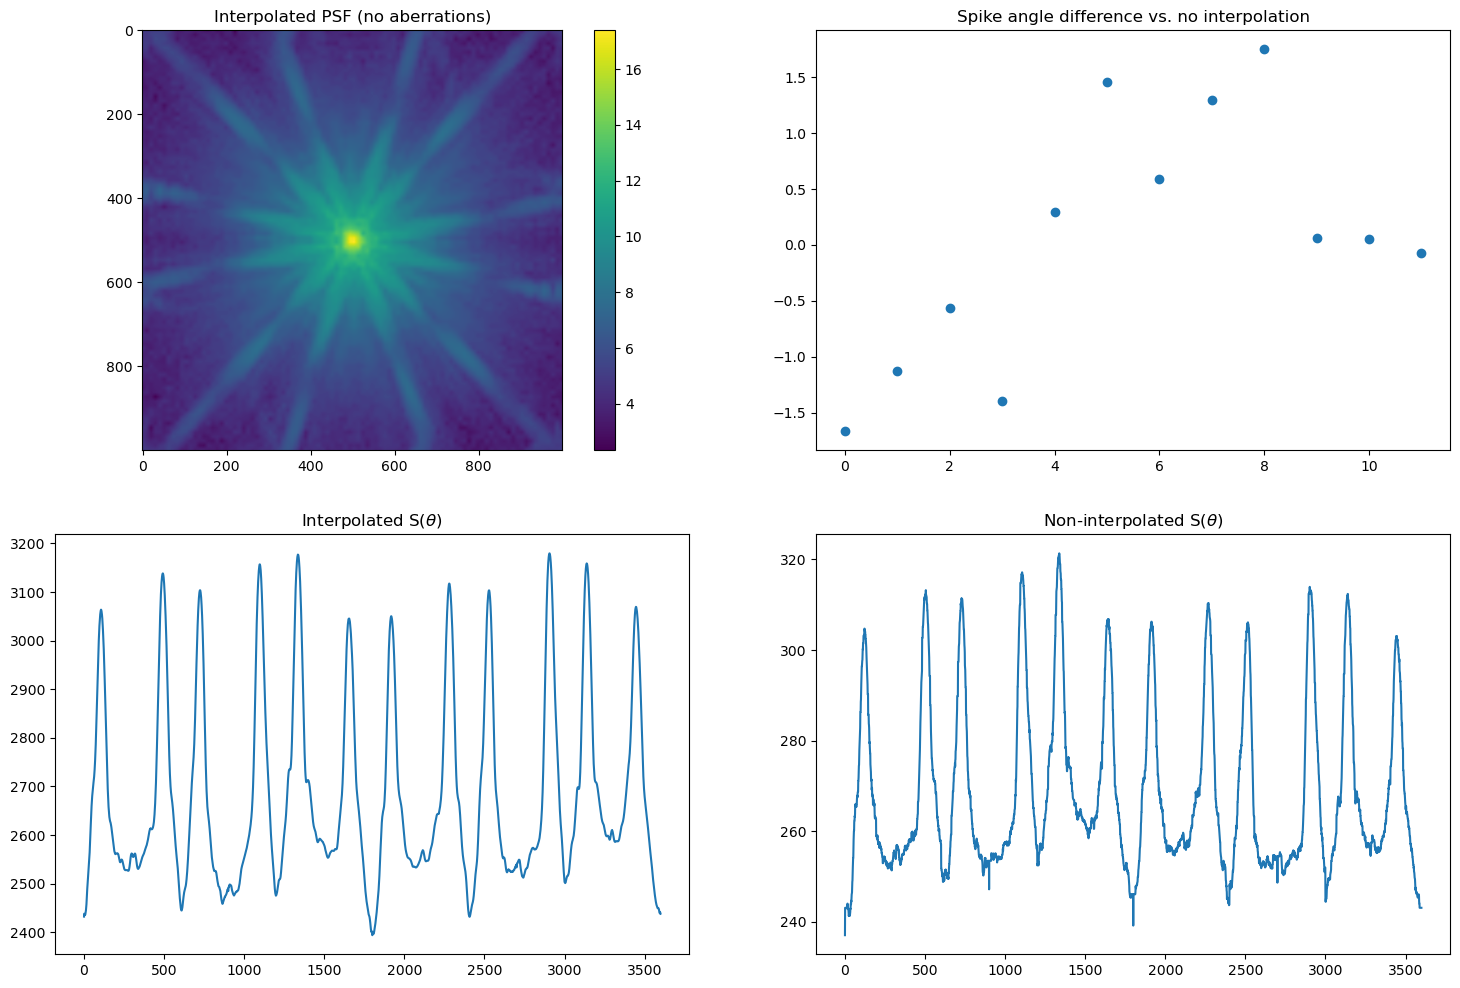

In [52]:
def interpolate_psf( img, dense_size ): # 2D ONLY
    x_pts = np.arange( img.shape[0] )
    y_pts = np.arange( img.shape[1] )

    new_grid = sp_itp.RegularGridInterpolator( ( x_pts, y_pts ), img, method='linear' )
    dense_x_1d = np.linspace( 0, img.shape[0] - 1, dense_size )
    dense_y_1d = np.linspace( 0, img.shape[1] - 1, dense_size )
    dense_x, dense_y = np.meshgrid( dense_x_1d, dense_y_1d, indexing='ij' )

    return new_grid( ( dense_x, dense_y ) )




x_pts = y_pts = np.arange( ps_size )

new_grid = sp_itp.RegularGridInterpolator( ( x_pts, y_pts ), psf_ideal, method='linear' )

# print( psf_ideal[ 40, 40 ] )

# print( new_grid( ( 40, 40 ) ) )

dense_ps_size = 1000
dense_bound = dense_ps_size // 2
dense_center = np.array( ( dense_ps_size // 2, dense_ps_size // 2 ) )

psf_ideal_dense = interpolate_psf( psf_ideal, dense_ps_size )

# dense_x_1d = dense_y_1d = np.linspace( 0, ps_size - 1, dense_ps_size )
# dense_x, dense_y = np.meshgrid( dense_x_1d, dense_y_1d, indexing='ij' )

fig, ax = plt.subplots( figsize=( 18, 12 ), ncols=2, nrows=2 )

# psf_ideal_dense = new_grid( ( dense_x, dense_y ) )
im = ax[0,0].imshow( psf_ideal_dense )
fig.colorbar( im, ax=ax[0,0] )

itp_sums, _, _, ideal_itp_spikes = find_spikes( psf_ideal_dense, step, dense_bound, dense_center, borders=borders, verbose=True )
N = np.arange( ideal_spikes.size )

ax[0,1].scatter( N, ideal_itp_spikes - ideal_spikes )

ax[1,0].plot( itp_sums )
ax[1,1].plot( ideal_sums )

ax[0,0].set_title( 'Interpolated PSF (no aberrations)' )
ax[0,1].set_title( 'Spike angle difference vs. no interpolation' )
ax[1,0].set_title( r'Interpolated S($\theta$)' )
ax[1,1].set_title( r'Non-interpolated S($\theta$)' )


In [46]:
j129_obj.compute_poly_psf( optical_psf_only=True, use_postage_stamp_size=ps_size, ovsamp=ovsamp, use_filter='J129', extra_aberrations = ( None, 0.1, ) )
psf_focus_pos = np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) )

psf_focus_pos_itp = interpolate_psf( psf_focus_pos, dense_ps_size )

j129_obj.compute_poly_psf( optical_psf_only=True, use_postage_stamp_size=ps_size, ovsamp=ovsamp, use_filter='J129', extra_aberrations = ( None, -0.1, ) )
psf_focus_neg = np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) )

psf_focus_neg_itp = interpolate_psf( psf_focus_neg, dense_ps_size )

j129_obj.compute_poly_psf( optical_psf_only=True, use_postage_stamp_size=ps_size, ovsamp=ovsamp, use_filter='J129', extra_aberrations = ( None, 0.02, ) )
psf_focus_small = np.arcsinh( poisson_resample_image(
    downsample_2d_image( np.abs( j129_obj.chromatic_psf ), pixel_size ),
    flux_factor
) )

psf_focus_small_itp = interpolate_psf( psf_focus_small, dense_ps_size )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


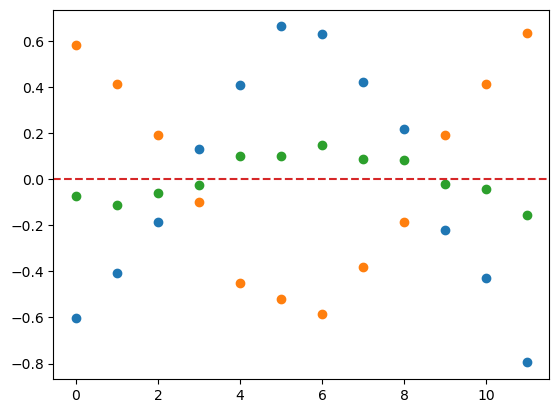

In [49]:
borders = ( 0.2, 1. )

focus_pos_itp_spikes = find_spikes( psf_focus_pos_itp, 0.1, dense_bound, dense_center, borders=borders )
focus_neg_itp_spikes = find_spikes( psf_focus_neg_itp, 0.1, dense_bound, dense_center, borders=borders )
focus_small_itp_spikes = find_spikes( psf_focus_small_itp, 0.1, dense_bound, dense_center, borders=borders )

plt.scatter( N, focus_pos_itp_spikes - ideal_itp_spikes )
plt.scatter( N, focus_neg_itp_spikes - ideal_itp_spikes )
plt.scatter( N, focus_small_itp_spikes - ideal_itp_spikes )
plt.axhline( 0, ls='--', color='C3' )

I don't have much hope that integrating along a line will solve the problem but if it's needed for a continuous and maybe differentiable $S(\theta)$ then the experimentation below may be useful

17.43116534200601
[351.81630344 355.36556069 373.65260529 398.61226746]


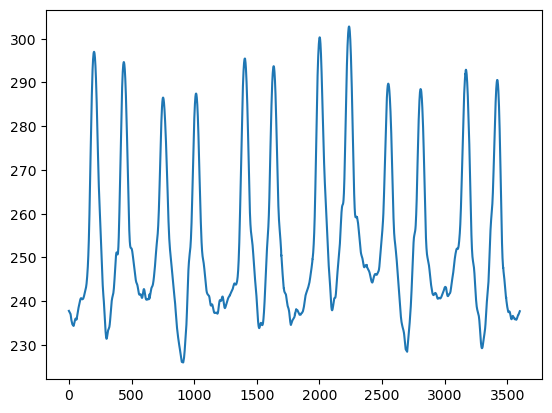

In [9]:
def xcoord( r, theta ):
    return r * np.cos( np.deg2rad( theta ) )

def ycoord( r, theta ):
    return r * np.sin( np.deg2rad( theta ) )

def polarize_psf_function( psf_func, center ): # RETURNS A FUNCTION

    return lambda r, theta: psf_func( ( xcoord( r, theta ) + center[0], ycoord( r, theta ) + center[1] ) )

polar_psf = polarize_psf_function( new_grid, center )


def integ_psf_along_radius( psf_func, theta, bound, center, borders=( 0., 1., ) ):
    true_bound = bound - 1
    psf_polar = polarize_psf_function( psf_func, center )
    psf_integ_once = lambda theta: (
        sp_int.quad(
            psf_polar, true_bound * borders[0], true_bound * borders[1], args=( theta, ),
            limit=200, epsabs=1e-3, epsrel=1e-3
        )[0]
    )
    psf_integ = np.vectorize( psf_integ_once )
    return psf_integ( theta )

print( polar_psf( 0, 0 ) )

grid = np.linspace( 0, borders[1]*(96//2 - 1), 400 )
# plt.plot( polar_psf( grid, 0 ) )
# plt.plot( polar_psf( grid, 9.2 ) )

angles = np.array( ( 0., 10., 40., 100., ) )
# sp_int.quad?
# print( sp_int.quad( polar_psf, 0, 47, args=( 44.5, ), limit=200, epsabs=1e-3, epsrel=1e-3 ) )
print( integ_psf_along_radius( new_grid, angles, bound, center ) )
angles = np.linspace( 0, 360, num=np.int32( 360. / step ), endpoint=False )
 
# unfortunately running quad 3600 times takes a couple of minutes
sums = integ_psf_along_radius( new_grid, angles, bound, center, borders=borders )
plt.plot( sums )

[ 20.45  44.    75.5  101.6  140.5  163.5  200.7  223.6  255.05 280.9
 316.9  341.6 ]


Text(0.5, 1.0, 'Confusing Result')

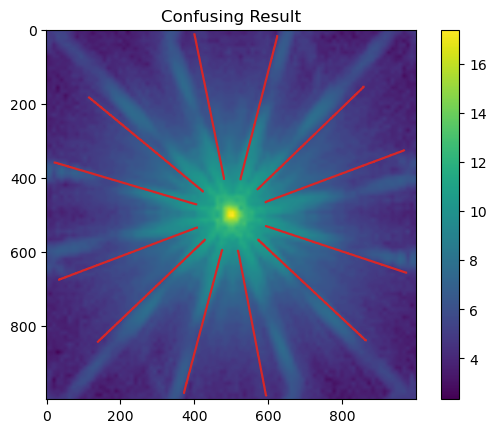

In [10]:
diff = np.max( sums ) - np.min( sums )
cutoff = np.min( sums ) + ( diff * 0.5 )
spike_indices = np.where( sums > cutoff )[0]
spike_angles = angles[ spike_indices ]
# print( np.diff( spike_angles ) )

# try 3 degrees to tell differing spikes apart for now
spike_angle_discriminator = 3.
borders = np.where( np.diff( spike_angles ) > spike_angle_discriminator )[0]
spike_groups = np.split( spike_angles, borders + 1 )
# print( spike_groups )

# unfortunately this for loop is necessary unless theres a convenient package for jagged arrays
spike_list = np.zeros( len( spike_groups ) )
for i in np.arange( len( spike_groups ) ):
    spike_list[i] = np.median( spike_groups[i] )

print( spike_list )


fig, ax = plt.subplots( )
im = ax.imshow( psf_ideal_dense )
fig.colorbar( im, ax=ax )
borders = ( 0.2, 1 )
for s in spike_list:
    draw_ray( ax, s, dense_bound, dense_center, borders=borders, color='C3' )

ax.set_title( 'Confusing Result' )